<a href="https://colab.research.google.com/github/Rana20063/Machine_Learning/blob/main/mybeloved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Merhaba,

Bu çalışma sayfasında araç görüntüsü üzerindeki plakanın yerini tespit etmeye çalışacağız.

Plaka yer tesipiti tüm resimler üzerinden değil rastgele seçilen bir fotoğraf üzerinden gerçekleşecektir. Aşağıdaki adımları uygularak yöntem diğer resimler ile de genelleştirilebilir.

İyi eğlenceler.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import kagglehub

In [4]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-plate-detection' dataset.
Path to dataset files: /kaggle/input/car-plate-detection


Plaka tespit çalışması yapmak için kullanacağım temel kütüphane CV2.

Aynı zamanda çalışmanın en altında yararlandığım ve faydalı olabileceğini düşündüğüm kaynakları paylaştım göz atablirsiniz.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

İşe önce seçeceğimiz herhangi bir resmi grafik üzerinde çizdirmekle başlayalım.

image read adında bir fonsiyon yaratarak 2 resim ve 2 başlık almasını söylüyoruz. İki resim olması nedeni resimleri birbirleri ile karşılaştırabilmemiz.

In [6]:
def image_read(image1, image2, title1 = "", title2 = ""):
    fig = plt.figure(figsize = (15, 15))
    ax1 = fig.add_subplot(121)
    ax1.imshow(image1, cmap = "gray")
    ax1.set(xticks = [], yticks = [], title = title1)
    ax2 = fig.add_subplot(122)
    ax2.imshow(image2, cmap = "gray")
    ax2.set(xticks = [], yticks = [], title = title2)

108 nolu resim seçildi. Farklı bir resimde denemek için 108 rakamı yerine data içerisindeki numaralardan herhangi birisini verebilirsiniz.

In [7]:
path = "/kaggle/input/car-plate-detection/images/Cars108.png"

Seçilen resmin görüntüsü aşağıdaki gibidir.

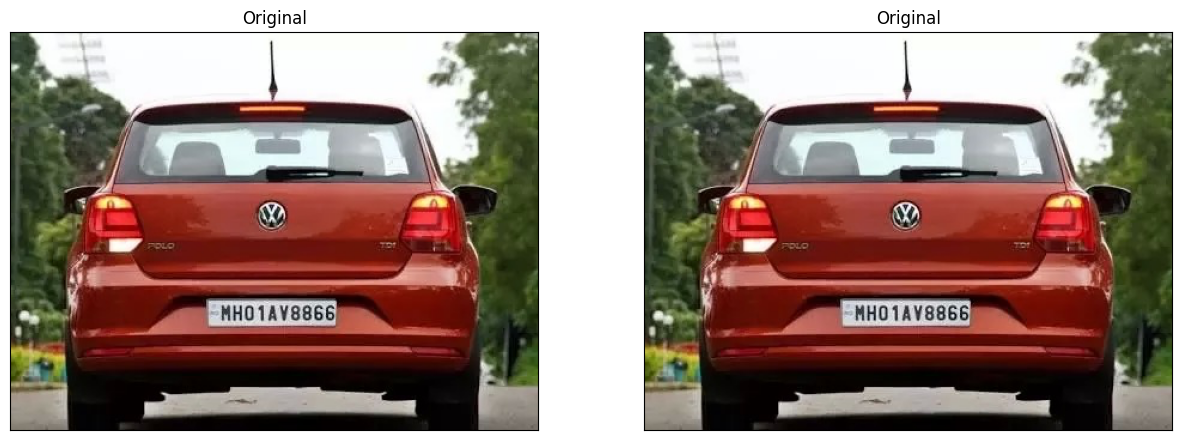

In [8]:
image = cv2.imread(path)

# Check if image loading was successful
if image is None:
    print(f"Error: Could not load image from {path}")
else:
    # Convert BGR image to RGB for matplotlib display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plot_image = image_read(image_rgb, image_rgb, title1 = "Original", title2 = "Original")

Resmi aldıktan sonra formatını değiştiriyoruz. RGB resimden Siyah-Beyaz resme geçiyoruz. Bunun nedeni işlemlerin siyah-beyaz görüntüler daha basit ve kolay olmasıdır. Normal RGB renklere sahip görüntülerin 3 kanalı bulunmaktadır siyah-beyaz görüntülerde ise kanal sayısı 1'dir. Kullanımı daha kolay olduğu için siyah-beyaz görüntü tercih edilmiştir.

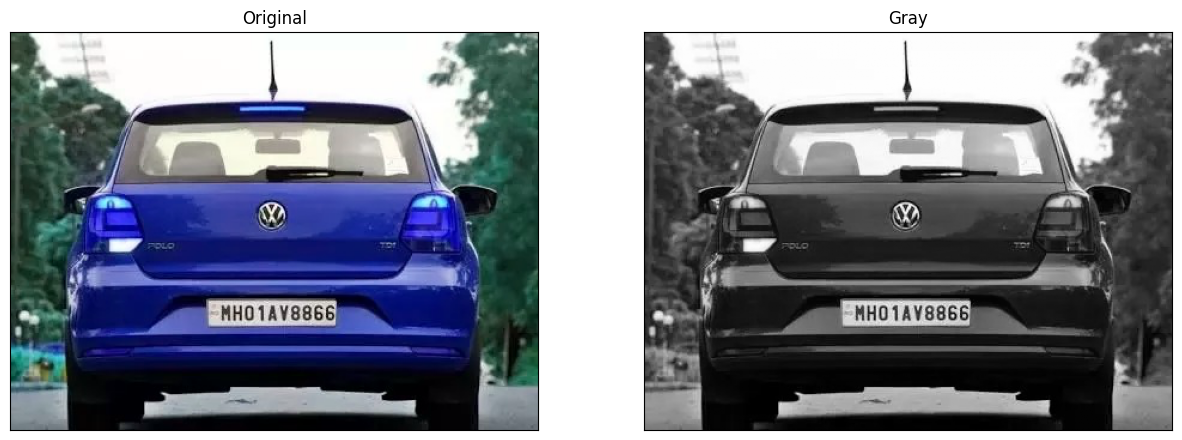

In [9]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

image_read(image, gray, title1 = "Original", title2 = "Gray")

Siyah-beyaz görüntüye çevirdikten sonra resmi flu hale getiriyoruz. Bunun nedeni ise resim üzerindeki gürültüleri temizlemektir. Resmin gürültüleri temizlendiğimde kenar ve köşe hatları daha keskin bir duruma gelir bunun faydası ise resimdeki birbirinden bağımsız objelerin daha rahat seçilmesini sağlar örneğin resimdeki arabanın başladığı yerler ilk resme kıyasla daha net belli olmaktadır aynı şekilde plaka ilk resme göre ikinci resimde daha belirgindir. Belirginden kasıt netlik değil karıştırmayalım belirginlikten kasıt görüntü içindeki farklılaşmayı ifade etmektedir.

Gürültü temizleme işlemi için cv2 içindeki bilateral filtre kullanılmıştır.

Bilateral Filtre için döküman --> [https://docs.opencv.org/master/d4/d13/tutorial_py_filtering.html](http://)

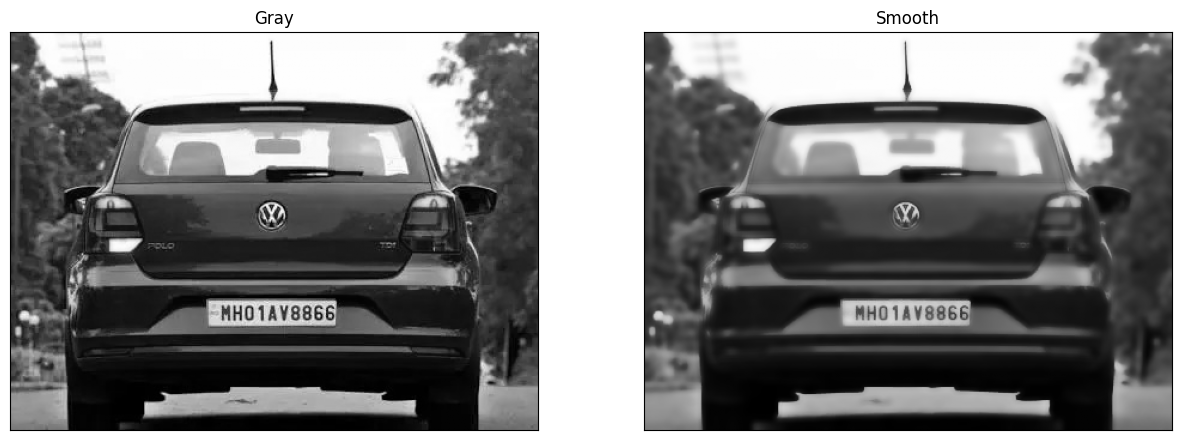

In [10]:
smooth = cv2.bilateralFilter(gray, 9, 75, 75)

image_read(gray, smooth, title1 = "Gray", title2 = "Smooth")

Flulaştırma işleminden sonra kenar ve köşelerin çizdirilmesi işlemi. Aşağıda görüldüğü gibi flu görüntüde kenar ve köşeler daha net çıkmaktadır. Resmin orjinal hali kullanılsa görüntü arka planındaki diğer objeler veya araca yansıyan gölgeler vs gibi bunlarında kenar ve köşeleri çizilecek böylece daha karmaşık bir görüntü elde edilecek.

Kenar köşe çizdirmek için yine cv2 içindeki Canny'i kullanıyorum. Canny fonksiyonu parametre olarak bir görüntü, minimum eşik değeri ve maksimum eşik değeri alıyor. Minimum ve maksimum eşik değerlerinin anlamı şu: çizilen bütün kenarlar içinden hangilerinin gerçek kenar hangilerinin ise gerçek olmayan kenarlar olduğunu tespit ediyor. Örneğin resmin arka planında bir sürü ağaç bulunmakta eğer max eşik değerini küçük tutarsak görüntü arka planında daha fazla kenar bulacak bu da görüntü daha karışık hale sokacaktır aynı zamanda max eşik değerini çok yüksek tutmak plaka yerinde herhangi bir kenar köşe bulamamasına neden olabilir.

Eğer kenar-köşe yoğunlu max eşiğin üzerinde ise bu kesinlikle kenardır, eğer kenar-köşe yoğunluğu min eşik değerinin altında ise burası kesinlikle kenar değildir mantığı ile çalışmaktadır.

Canny --> [https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_canny/py_canny.html](http://)

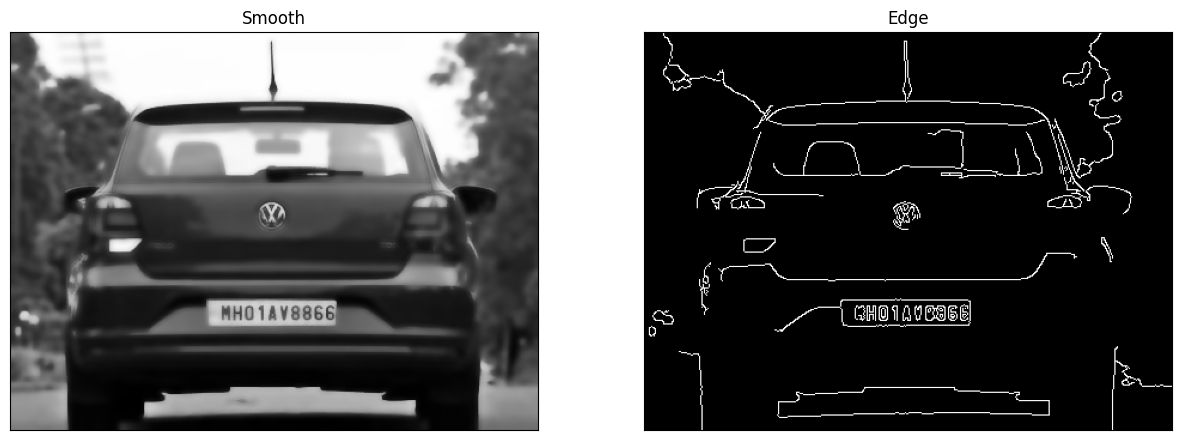

In [11]:
edge = cv2.Canny(smooth, 70, 400)
image_read(smooth, edge, title1 = "Smooth", title2 = "Edge")

Kenar-köşe tespiti sonrasında kontur işlemine geldik. Buradaki mantık aynı renk ve yoğunluğa sahip olan tüm kesintisiz noktaları sınırları boyunca birleştirir. Yani kısaca kenar ve köşeleri çerçeve içine alıyor diyebiliriz.

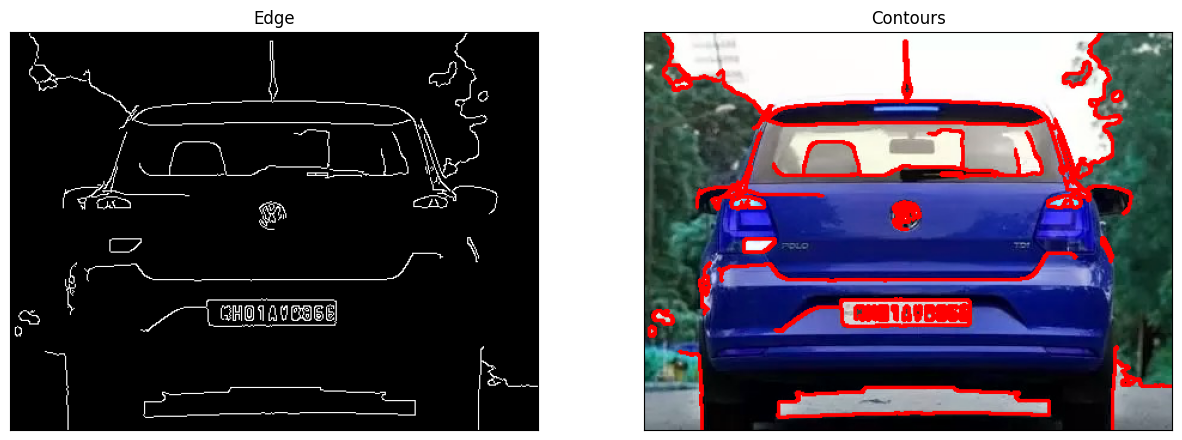

In [12]:
contours, new = cv2.findContours(edge.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

image_copy = image.copy()

_ = cv2.drawContours(image_copy, contours, -1, (255, 0, 0), 2)

image_read(edge, image_copy, title1 = "Edge", title2 = "Contours")

Kontur işleminden sonra çıkan tüm konturların alan büyüklüklerine göre sıralıyoruz. En fazla alana sahip 5 (bu resme ait olan-değişebilir.) konturu işaretliyoruz. Yani küçük alana sahip olanlar eleniyor, örneğin yukarıdaki ağaçların sahip olduğu bazı alanlar gibi.

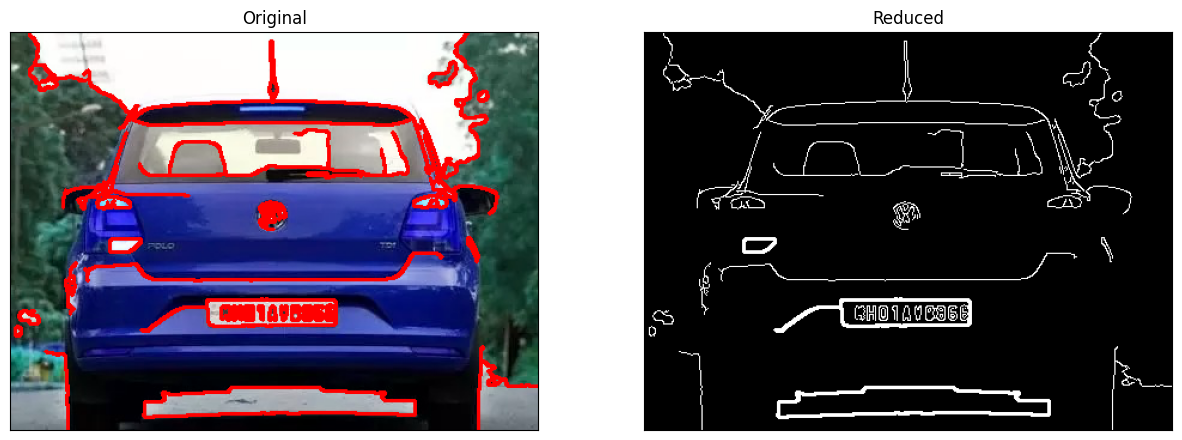

In [13]:
contours = sorted(contours, key = cv2.contourArea, reverse = True)[:5]

image_reduced = edge.copy()
_ = cv2.drawContours(image_reduced, contours, -1, (255, 0, 0), 2)

image_read(image_copy, image_reduced, title1 = "Original", title2 = "Reduced")

Son aşamada yukarı aldığımız 5 kontur için yaptığımız işlem uzunluklarını hesaplamak ve aralarındaki dikdörgene(plaka şekli) benzeyen kontur için resim üzerindeki koordinatlarını tespit etmek. Koordinatlar tespit edildikten sonra resim üzerinde bulunana bu koordinatlara ait alan kesilerek plakaya ait olması muhtemel alan elimizde kalıyor.

Tekrar söylemekte fayda var bu eşik değerleri, max kontur sayısı bu resim için geçerlidir. Data içindeki diğer resimlerde de çalışabilir fakat tamamında aynı değerler ile kullanılması her seferinde plakayı doğru getireceğini garanti etmez.

In [14]:
plate = None

for i in contours:
    a = cv2.arcLength(i, True)
    edge_count = cv2.approxPolyDP(i, 0.02 * a, True)
    if len(edge_count) == 5:
        x, y, w, h = cv2.boundingRect(i)
        plate = image[y:y+h, x:x+w]
        break

cv2.imwrite("plate.png", plate)

True

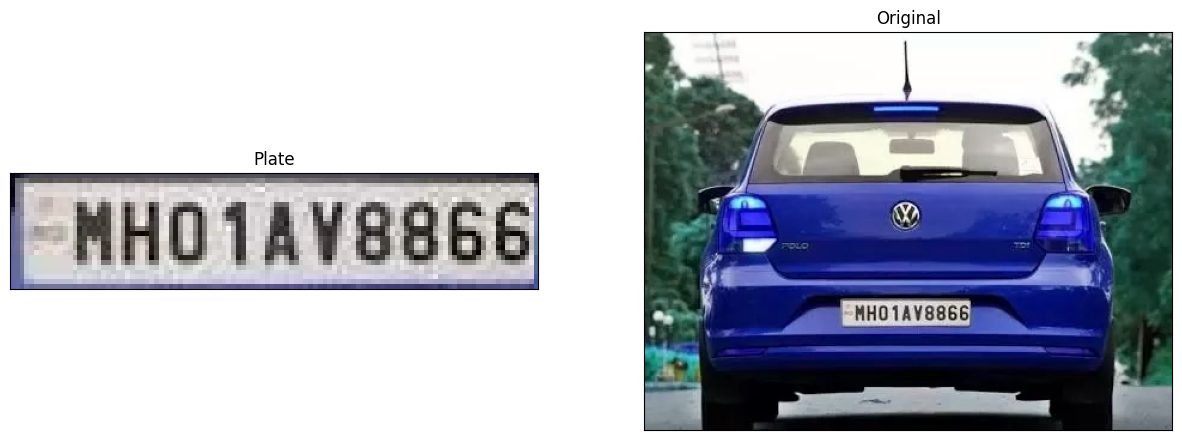

In [15]:
image_read(plate, image, title1 = "Plate", title2 = "Original")

## Plaka Üzerindeki Metni OCR ile Tanıma

Şimdi, tespit ettiğimiz plaka görüntüsü üzerindeki metni okumak için Optik Karakter Tanıma (OCR) kullanacağız. Bunun için `pytesseract` kütüphanesini ve temel Tesseract OCR motorunu kurmamız gerekiyor.

In [17]:
# Tesseract OCR motorunu kurma
!sudo apt update
!sudo apt install tesseract-ocr

# pytesseract kütüphanesini kurma
!pip install pytesseract

# Gerekli kütüphaneleri içe aktarma
import pytesseract
from PIL import Image


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 1s (2,720 B/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
13 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading pa

Tesseract'ın daha iyi performans göstermesi için plakayı ön işlemden geçirebiliriz (örneğin gri tonlama ve eşikleme). Ancak, `cv2.imread` ile kaydettiğimiz `plate.png` dosyasını doğrudan `pytesseract`'e geçirebiliriz.

In [18]:
# Kaydedilen plaka resmini yükle (orijinal plate objesini kullanacağız)
# plate_image_for_ocr = Image.open("plate.png") # Bu satırı artık kullanmayacağız

# OCR için plakayı ön işlemden geçir
# 1. Gri tonlamaya çevir
gray_plate = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

# 2. Resim boyutunu büyüt (Tesseract küçük resimlerde daha kötü çalışabilir)
# Bu oran deneme yanılma ile bulunabilir
scale_factor = 2
resized_plate = cv2.resize(gray_plate, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

# 3. İkili (binary) eşikleme uygula
# Eşik değeri ve tipini deneme yanılma ile ayarlayabilirsiniz.
# Örneğin, cv2.THRESH_BINARY_INV, metni beyaz ve arka planı siyah yapabilir.
_, threshold_plate = cv2.threshold(resized_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Görüntüyü Pillow formatına dönüştür
plate_image_for_ocr = Image.fromarray(threshold_plate)

# Görüntüyü göster (isteğe bağlı)
# display(plate_image_for_ocr)

# Tesseract için özel konfigürasyonlar (örn: sadece alfanümerik karakterler)
tesseract_config = r'--oem 3 --psm 8 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

# OCR kullanarak metni çıkar
plate_text = pytesseract.image_to_string(plate_image_for_ocr, config=tesseract_config)

print(f"Plakadan çıkarılan metin: {plate_text.strip()}")

Plakadan çıkarılan metin: MHO1AV8866
